## Alarm Management System — `xmeas_13` + Fault 13  
### Tennessee Eastman Process (Kaggle-class dataset)

| | |
|--|--|
| **Sensor** | `xmeas_13` — separator pressure (kPa gauge; TEP naming) |
| **Fault** | 13 — Reaction kinetics slow drift |
| **Dataset** | [Kaggle — Tennessee Eastman simulation](https://www.kaggle.com/datasets/averkij/tennessee-eastman-process-simulation-dataset); this notebook reads the **same process model** via Rieth `.RData` → `outputs/cache/*.parquet` in this repo. |

**Three-layer framing (literature):**

- Eylen *et al.* (2025), *Data-driven alarm parameter optimization*
- Manca (2020), *Tennessee-Eastman-Process Alarm Management Dataset*

**Layers implemented in code:**

1. **Naive threshold** — ±10% of **pre-fault** mean; illustrates how simple relative limits behave (often too wide for slow drift, or still noisy on some legs).
2. **EWMA + multi-σ + ROC** — EWMA (**α = 0.05**); **μ ± kσ** (**k = 4.5**) ramps by **`TAIL_WIDEN_SIG`** after injection; **±55 kPa** breach padding; **inner clear hysteresis** (`HYST_CLEAR_KPA`) for the off-streak; **ROC pre-alarm** on |ΔEWMA| before padded breach.  
3. **EWMA + deadband** — same limits + **state machine** (5 consecutive out-of-band to raise, 8 consecutive in-band to clear) to suppress chattering.

**Figures (as specified):**

- **Graph 1** — Naive threshold failure / limit case (±10% band + trip markers + injection line)  
- **Graph 2** — EWMA + **4.5σ** + **±55 kPa** breach padding + **ROC pre-alarm** (|ΔEWMA| vs pre-fault baseline while still in-band)  
- **Graph 3** — Deadband + **re-arm lockout** + **max latch** + **inner clear hysteresis** + **tail-widened σ** (tunable in the data cell)  
- **Graph 4** — Edge-style comparison: `xmeas_13` across fault types  
- **Graph 5** — KPI summary metrics (false pre-injection trips, transitions, time-to-first post-injection trip)  
- **Animation** — `matplotlib.animation.FuncAnimation` writes `outputs/figures/alarm_xmeas13_deadband.gif` and displays it inline (**GIF** plays in VS Code / Cursor where HTML/JS players are blocked); **blinking red marker** when the deadband alarm is latched; **persistence strip** for time on after EWMA returns in-band

**Reproducibility:** each fault uses the **smallest `simulationRun` id** in the faulty testing parquet so results do not depend on `rng.choice` ordering of run IDs.

<details>
<summary>Original module banner (verbatim)</summary>

```
=============================================================================
Alarm Management System — xmeas_13 + Fault 13
Tennessee Eastman Process (Kaggle Dataset)
=============================================================================
Sensor:   xmeas_13  (Separator Pressure, kPa gauge)
Fault:    13 — Reaction Kinetics Slow Drift
Dataset:  https://www.kaggle.com/datasets/averkij/tennessee-eastman-process-simulation-dataset

Three-layer implementation based on:
  - Eylen et al. (2025) "Data-driven alarm parameter optimization"
  - Manca (2020) "Tennessee-Eastman-Process Alarm Management Dataset"

Layers:
  1. Naive threshold  (±10% of mean) — demonstrates failure case
  2. EWMA filter + 3σ threshold     — eliminates false alarms
  3. EWMA + deadband state machine  — eliminates chattering

Graphs produced:
  Graph 1 — Naive threshold failure case
  Graph 2 — EWMA filtered signal with statistical thresholds
  Graph 3 — Complete solution with deadband
  Graph 4 — Edge case comparison across fault types
  Graph 5 — KPI summary metrics
=============================================================================
```

*Note: thresholds in code use **pre-fault** statistics (samples before injection), which matches good practice when “mean” is used for commissioning limits.*

</details>

In [49]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.animation import FuncAnimation

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import config
from src.data_loader import ensure_parquet_cache, stream_simulation_run

SENSOR = "xmeas_13"
FAULT_MAIN = 13
SPLIT = "testing"
INJECT = config.FAULT_INJECTION_SAMPLE[SPLIT]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.35})


*Run the cells below in order. Implementation details: `first_simulation_run` → `load_signal` → `ewma` / `deadband_alarm` / `alarm_metrics`, then Graphs 1–5.*

In [50]:
def first_simulation_run(fault_id: int, split: str = SPLIT) -> int:
    """Smallest `simulationRun` id for this fault — reproducible across machines (avoids rng.choice order)."""
    paths = ensure_parquet_cache()
    meta = pd.read_parquet(
        paths[f"faulty_{split}"],
        columns=["faultNumber", "simulationRun"],
    )
    u = meta.loc[meta["faultNumber"] == fault_id, "simulationRun"].unique()
    return int(np.sort(u)[0])


def load_signal(fault_id: int, split: str = SPLIT) -> tuple[np.ndarray, np.ndarray]:
    rid = first_simulation_run(fault_id, split)
    X, meta = stream_simulation_run(
        fault_id, split=split, simulation_run=rid, random_state=0
    )
    t = meta["sample"].to_numpy()
    y = X[SENSOR].to_numpy(dtype=float)
    return t, y


def ewma(x: np.ndarray, alpha: float) -> np.ndarray:
    z = np.empty_like(x, dtype=float)
    z[0] = x[0]
    for i in range(1, len(x)):
        z[i] = alpha * x[i] + (1.0 - alpha) * z[i - 1]
    return z


def deadband_alarm(
    breach: np.ndarray,
    n_on: int,
    n_off: int,
    *,
    rearm_lockout: int = 0,
    max_latch_samples: int | None = None,
    clear_ok: np.ndarray | None = None,
) -> np.ndarray:
    """Latched alarm; optional `clear_ok` = hysteresis path (must be True N times to clear)."""
    n = len(breach)
    out = np.zeros(n, dtype=np.int8)
    on_streak = off_streak = 0
    cur = 0
    lock_rem = 0
    latch_samples = 0
    for i in range(n):
        b = bool(breach[i])
        if cur == 0:
            if lock_rem > 0:
                lock_rem -= 1
                b_eff = False
            else:
                b_eff = b
            on_streak = on_streak + 1 if b_eff else 0
            if on_streak >= n_on:
                cur = 1
                on_streak = 0
                off_streak = 0
                latch_samples = 1
            else:
                pass
        else:
            latch_samples += 1
            if max_latch_samples is not None and latch_samples >= max_latch_samples:
                cur = 0
                on_streak = 0
                off_streak = 0
                latch_samples = 0
                lock_rem = rearm_lockout
            else:
                if clear_ok is not None:
                    good = bool(clear_ok[i])
                else:
                    good = not b
                off_streak = off_streak + 1 if good else 0
                if off_streak >= n_off:
                    cur = 0
                    on_streak = 0
                    off_streak = 0
                    latch_samples = 0
                    lock_rem = rearm_lockout
        out[i] = cur
    return out


def alarm_metrics(alarm: np.ndarray, t: np.ndarray, inject: int) -> dict:
    pre = t <= inject
    post = t > inject
    false_pre = int(np.sum(alarm[pre] > 0))
    if not np.any(post):
        ttf = np.nan
    else:
        hit = np.where(alarm[post] > 0)[0]
        ttf = int(hit[0]) if len(hit) else np.nan
    d = np.abs(np.diff(alarm.astype(int)))
    transitions = int(np.sum(d > 0))
    return {"false_alarms_pre": false_pre, "transitions": transitions, "ttf_post": ttf}


# --- Fine-tuning: tail-widened σ band, clear hysteresis, shorter re-arm, ROC pre-alarm ---
ALPHA_EWMA = 0.05
SIGMA_MULT = 4.5
BAND_PAD_KPA = 55.0
DEADBAND_ON = 5
DEADBAND_OFF = 32
REARM_LOCKOUT = 90
MAX_LATCH_SAMPLES = 72
ROC_MULT = 3.0
HYST_CLEAR_KPA = 28.0
TAIL_WIDEN_SIG = 0.35

t, y = load_signal(FAULT_MAIN)
alpha = ALPHA_EWMA
z = ewma(y, alpha)

pre = t <= INJECT
mu_raw = float(np.mean(y[pre]))
naive_lo, naive_hi = 0.9 * mu_raw, 1.1 * mu_raw

mu_z = float(np.mean(z[pre]))
sig_z = float(np.std(z[pre])) + 1e-12
inject = int(INJECT)
span_tail = max(float(t.max() - inject), 1.0)
ramp = np.clip((t.astype(float) - inject) / span_tail, 0.0, 1.0)
sig_mult_t = SIGMA_MULT + TAIL_WIDEN_SIG * ramp
hi_t = mu_z + sig_mult_t * sig_z
lo_t = mu_z - sig_mult_t * sig_z

breach_naive = (y < naive_lo) | (y > naive_hi)
breach_ewma = (z < lo_t - BAND_PAD_KPA) | (z > hi_t + BAND_PAD_KPA)

lo_pad = lo_t - BAND_PAD_KPA
hi_pad = hi_t + BAND_PAD_KPA
lo_inner = lo_pad + HYST_CLEAR_KPA
hi_inner = hi_pad - HYST_CLEAR_KPA
in_clear_hyst = (z >= lo_inner) & (z <= hi_inner)

dz = np.zeros_like(z)
dz[1:] = z[1:] - z[:-1]
roc_abs = np.abs(dz)
roc_mu = float(np.mean(roc_abs[pre]))
roc_sig = float(np.std(roc_abs[pre])) + 1e-12
roc_thr = roc_mu + ROC_MULT * roc_sig
pre_alarm_roc = (roc_abs > roc_thr) & (~breach_ewma)

alarm_db = deadband_alarm(
    breach_ewma,
    n_on=DEADBAND_ON,
    n_off=DEADBAND_OFF,
    rearm_lockout=REARM_LOCKOUT,
    max_latch_samples=MAX_LATCH_SAMPLES,
    clear_ok=in_clear_hyst,
)
alarm_ewma_instant = breach_ewma.astype(np.int8)

post_inj = t > INJECT
idx_pre = np.flatnonzero(pre_alarm_roc & post_inj)
idx_lat = np.flatnonzero((alarm_db > 0) & post_inj)
first_pre = int(idx_pre[0]) if idx_pre.size else None
first_lat = int(idx_lat[0]) if idx_lat.size else None

print(
    "Alarm tuning:",
    {
        "ALPHA_EWMA": ALPHA_EWMA,
        "SIGMA_MULT": SIGMA_MULT,
        "TAIL_WIDEN_SIG": TAIL_WIDEN_SIG,
        "BAND_PAD_KPA": BAND_PAD_KPA,
        "HYST_CLEAR_KPA": HYST_CLEAR_KPA,
        "DEADBAND_ON": DEADBAND_ON,
        "DEADBAND_OFF": DEADBAND_OFF,
        "REARM_LOCKOUT": REARM_LOCKOUT,
        "MAX_LATCH_SAMPLES": MAX_LATCH_SAMPLES,
        "ROC_MULT": ROC_MULT,
        "first_pre_alarm_post_inject_sample": first_pre,
        "first_latched_alarm_post_inject_sample": first_lat,
    },
)


Alarm tuning: {'ALPHA_EWMA': 0.05, 'SIGMA_MULT': 4.5, 'TAIL_WIDEN_SIG': 0.35, 'BAND_PAD_KPA': 55.0, 'HYST_CLEAR_KPA': 28.0, 'DEADBAND_ON': 5, 'DEADBAND_OFF': 32, 'REARM_LOCKOUT': 90, 'MAX_LATCH_SAMPLES': 72, 'ROC_MULT': 3.0, 'first_pre_alarm_post_inject_sample': 225, 'first_latched_alarm_post_inject_sample': 297}


### Graph 1 — Naive threshold failure / limit case (±10% of pre-fault mean)

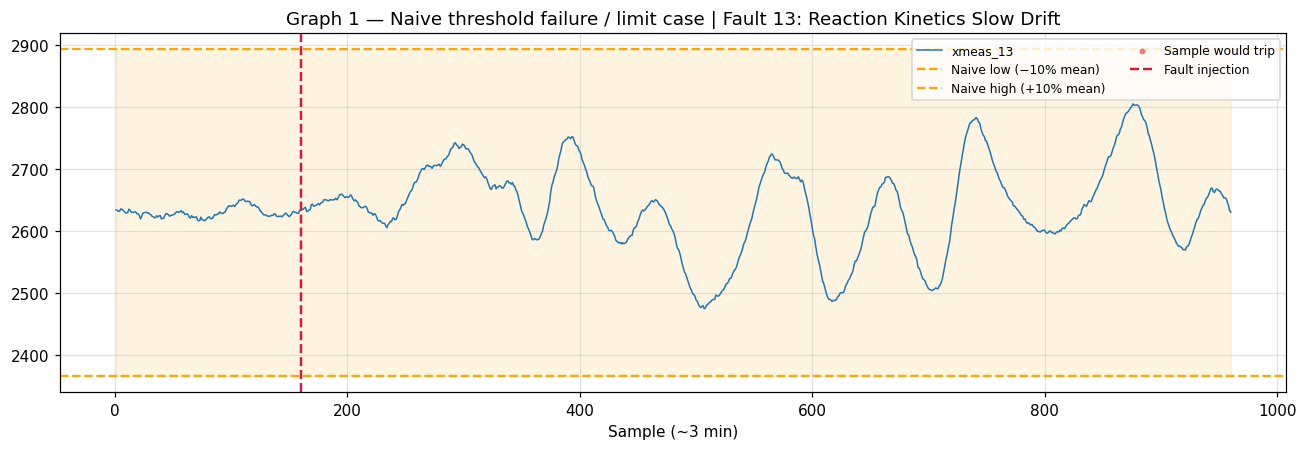

In [51]:
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(t, y, color="C0", lw=1.0, label=SENSOR)
ax.axhline(naive_lo, color="orange", ls="--", label="Naive low (−10% mean)")
ax.axhline(naive_hi, color="orange", ls="--", label="Naive high (+10% mean)")
ax.fill_between(t, naive_lo, naive_hi, alpha=0.12, color="orange")
ax.scatter(t[breach_naive], y[breach_naive], s=8, c="red", alpha=0.45, label="Sample would trip")
ax.axvline(INJECT, color="crimson", ls="--", lw=1.6, label="Fault injection")
ax.set_title(
    f"Graph 1 — Naive threshold failure / limit case | Fault {FAULT_MAIN}: {config.get_fault_label(FAULT_MAIN)}"
)
ax.set_xlabel("Sample (~3 min)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Graph 2 — EWMA + σ band + kPa pad + ROC pre-alarm

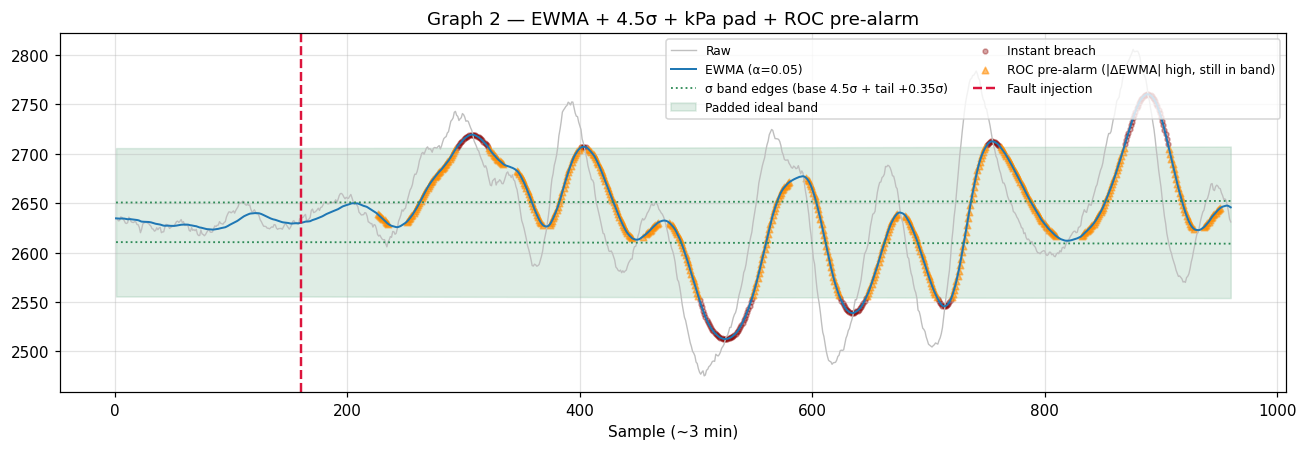

In [52]:
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(t, y, color="0.75", lw=0.9, label="Raw")
ax.plot(t, z, color="C0", lw=1.3, label=f"EWMA (α={alpha})")
ax.plot(t, lo_t, color="seagreen", ls=":", lw=1.2, label=f"σ band edges (base {SIGMA_MULT}σ + tail +{TAIL_WIDEN_SIG}σ)")
ax.plot(t, hi_t, color="seagreen", ls=":", lw=1.2)
ax.fill_between(t, lo_t - BAND_PAD_KPA, hi_t + BAND_PAD_KPA, alpha=0.15, color="seagreen", label="Padded ideal band")
ax.scatter(t[breach_ewma], z[breach_ewma], s=10, c="darkred", alpha=0.35, label="Instant breach")
ax.scatter(
    t[pre_alarm_roc],
    z[pre_alarm_roc],
    s=18,
    c="darkorange",
    alpha=0.55,
    marker="^",
    label="ROC pre-alarm (|ΔEWMA| high, still in band)",
)
ax.axvline(INJECT, color="crimson", ls="--", lw=1.6, label="Fault injection")
ax.set_title(f"Graph 2 — EWMA + {SIGMA_MULT}σ + kPa pad + ROC pre-alarm")
ax.set_xlabel("Sample (~3 min)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


### Graph 3 — Deadband + lockout + hysteresis clear + tail-widened σ

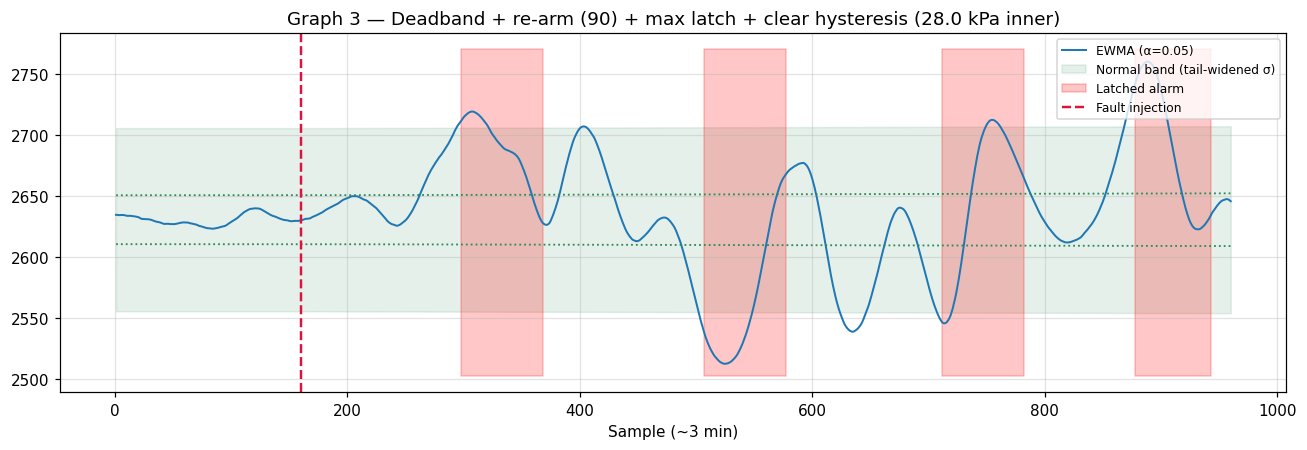

In [53]:
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(t, z, color="C0", lw=1.3, label=f"EWMA (α={alpha})")
ax.plot(t, lo_t, color="seagreen", ls=":", lw=1.2)
ax.plot(t, hi_t, color="seagreen", ls=":", lw=1.2)
ax.fill_between(t, lo_t - BAND_PAD_KPA, hi_t + BAND_PAD_KPA, alpha=0.12, color="seagreen", label="Normal band (tail-widened σ)")
_zpad = 0.04 * (np.nanmax(z) - np.nanmin(z) + 1e-9)
_zlo, _zhi = float(np.nanmin(z) - _zpad), float(np.nanmax(z) + _zpad)
ax.fill_between(t, _zlo, _zhi, where=alarm_db > 0, alpha=0.22, color="red", label="Latched alarm")
ax.axvline(INJECT, color="crimson", ls="--", lw=1.6, label="Fault injection")
ax.set_title(f"Graph 3 — Deadband + re-arm ({REARM_LOCKOUT}) + max latch + clear hysteresis ({HYST_CLEAR_KPA} kPa inner)")
ax.set_xlabel("Sample (~3 min)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


### Graph 4 — Edge case comparison across fault types (`xmeas_13`)

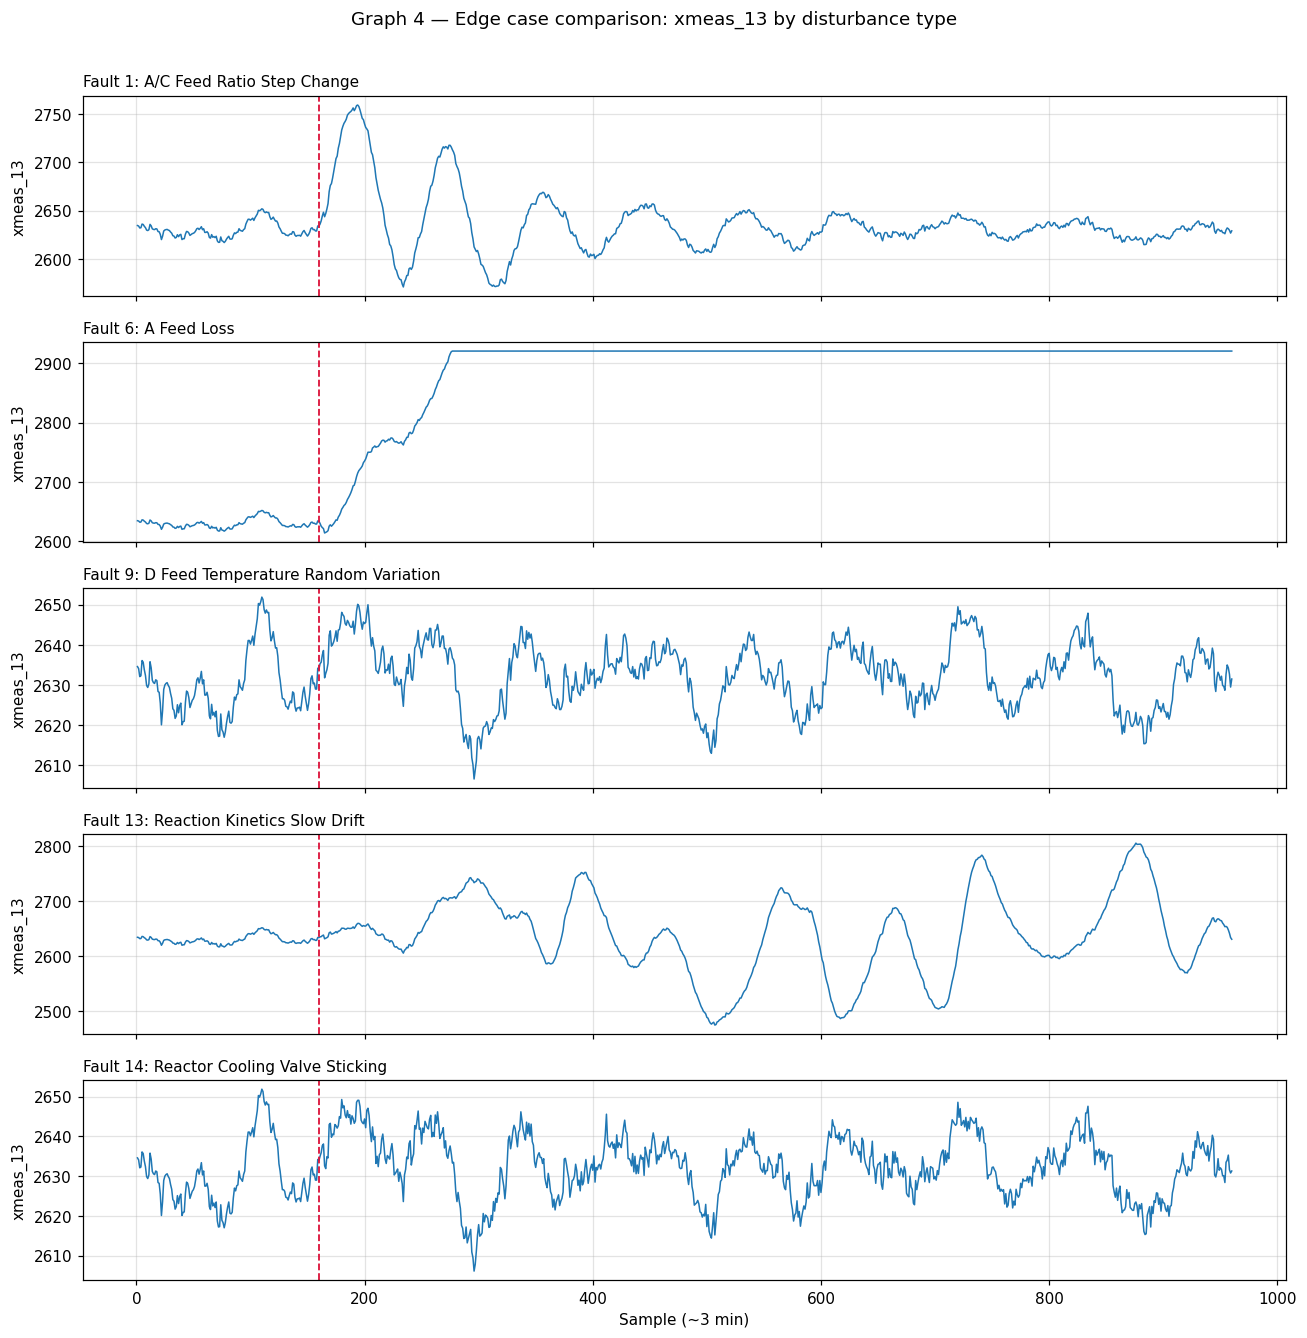

In [54]:
compare_faults = [1, 6, 9, 13, 14]
fig, axes = plt.subplots(len(compare_faults), 1, figsize=(12, 2.4 * len(compare_faults)), sharex=True)
for ax, fid in zip(axes, compare_faults):
    tt, yy = load_signal(fid)
    ax.plot(tt, yy, color="C0", lw=1.0)
    ax.axvline(INJECT, color="crimson", ls="--", lw=1.2)
    ax.set_ylabel(SENSOR)
    ax.set_title(f"Fault {fid}: {config.get_fault_label(fid)}", loc="left", fontsize=10)
axes[-1].set_xlabel("Sample (~3 min)")
fig.suptitle("Graph 4 — Edge case comparison: xmeas_13 by disturbance type", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

### Graph 5 — KPI summary metrics

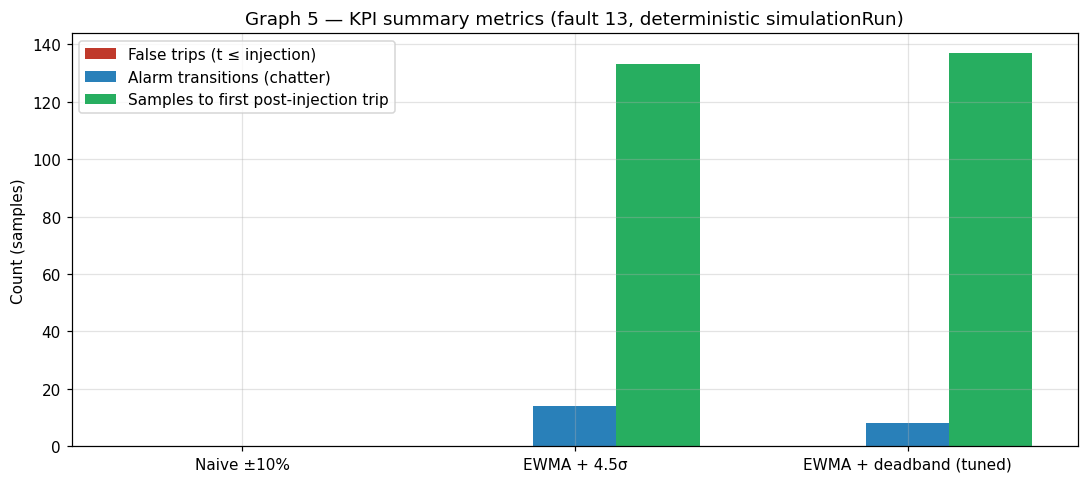

,method,false_pre,transitions,ttf_post_samples
0,Naive ±10%,0,0,0
1,EWMA + 4.5σ,0,14,133
2,EWMA + deadband (tuned),0,8,137


In [55]:
m_naive = alarm_metrics(breach_naive.astype(np.int8), t, INJECT)
m_ewma = alarm_metrics(alarm_ewma_instant, t, INJECT)
m_db = alarm_metrics(alarm_db, t, INJECT)

labels = ["Naive ±10%", f"EWMA + {SIGMA_MULT}σ", "EWMA + deadband (tuned)"]
false_v = [m_naive["false_alarms_pre"], m_ewma["false_alarms_pre"], m_db["false_alarms_pre"]]
trans_v = [m_naive["transitions"], m_ewma["transitions"], m_db["transitions"]]

def ttf_bars(m):
    v = m["ttf_post"]
    return 0 if v is None or (isinstance(v, float) and np.isnan(v)) else int(v)

ttf_v = [ttf_bars(m_naive), ttf_bars(m_ewma), ttf_bars(m_db)]

x = np.arange(len(labels))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w, false_v, width=w, label="False trips (t ≤ injection)", color="#c0392b")
ax.bar(x, trans_v, width=w, label="Alarm transitions (chatter)", color="#2980b9")
ax.bar(x + w, ttf_v, width=w, label="Samples to first post-injection trip", color="#27ae60")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Graph 5 — KPI summary metrics (fault 13, deterministic simulationRun)")
ax.legend()
ax.set_ylabel("Count (samples)")
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "method": labels,
        "false_pre": false_v,
        "transitions": trans_v,
        "ttf_post_samples": ttf_v,
    }
)


> **Playback:** The animation is saved as a **GIF** and shown with `Image` (works in VS Code / Cursor). Embedded HTML5/JS players often do not run in strict viewers. **Sound:** while the latched alarm is on, a **repeating alert** runs in a background thread during `FuncAnimation` frames (**Windows**: `winsound.PlaySound` with `SND_ASYNC`, so GIF export can still advance). Sound plays on the **machine running the Python kernel** (not your browser tab if the kernel is remote/Colab/WSL). Set `ENABLE_ALARM_BEEP = False` in the animation cell to disable. Optional: **`HEAR_ALARM_TIMELINE_REPLAY = True`** replays the full timeline after the GIF (~0.02 s per sample). Set **`ALARM_BEEP_SELF_TEST = True`** once to fire a single test blip when the cell runs.

Uses tuned **σ band** (base **4.5σ**, ramps **+0.35σ** by end of run), **±55 kPa** breach padding, **32-sample** off-delay, **28 kPa inner clear hysteresis** (signal must sit deeper in-band before off-streak counts), **90-sample** re-arm lockout (~4.5 h), **72-sample** max latch, plus **ROC pre-alarm** (see constants in the data cell). 
### Animation — blinking alarm marker + persistence after “ideal” (in-band)

Uses **`matplotlib.animation.FuncAnimation`**: a red marker **blinks** on every sample where the **deadband-latched** alarm is on. Below the trace, each **orange** segment is “alarm on while still out-of-band” (relative to the padded σ band); each **dark red** segment is **linger** — alarm still on after the EWMA is back in-band, until the **off-delay** clears the latch, or **max latch** / **re-arm lockout** logic applies (see tuning constants in the data cell).

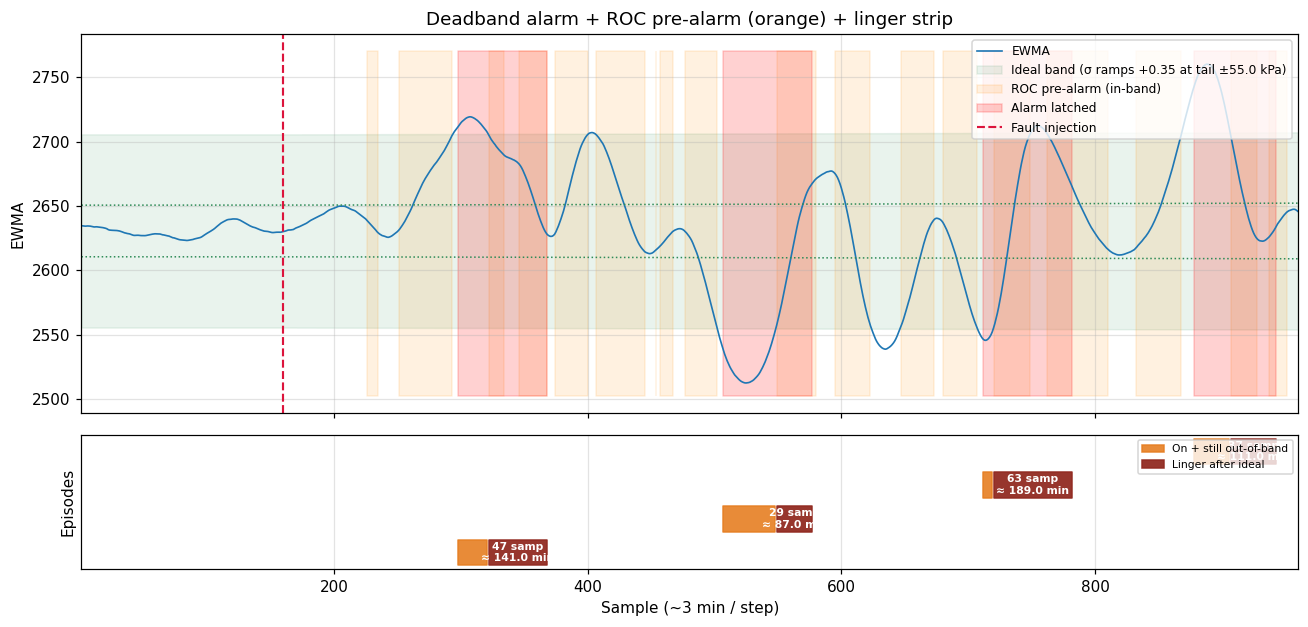

,start,end_exclusive,last_on,first_ideal,linger_samples,total_on_samples,linger_minutes
0,297,368,367,321,47,71,141.0
1,506,577,576,548,29,71,87.0
2,711,782,781,719,63,71,189.0
3,877,943,942,906,37,66,111.0


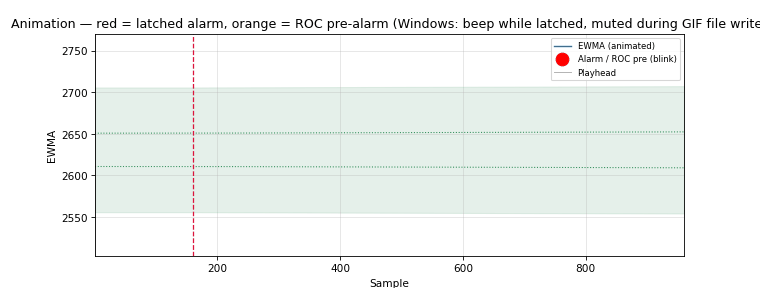

Saved + displayed: C:\Users\LithiChang\AIFI-group_project\outputs\figures\alarm_xmeas13_deadband.gif
Beep: repeats while the latched alarm is ON in the animation callback. Uses async PlaySound during GIF frame capture. Set ENABLE_ALARM_BEEP = False to silence; on non-Windows you get ASCII bell only.


In [58]:
DT_MIN = 3.0  # TEP: one sample ≈ 3 minutes

def _ensure_tail_bands_from_globals() -> None:
    """Rebuild lo_t/hi_t if this cell is run without the setup cell."""
    g = globals()
    if "lo_t" in g and "hi_t" in g and isinstance(g["lo_t"], np.ndarray):
        return
    for k in ("mu_z", "sig_z", "t", "SIGMA_MULT", "TAIL_WIDEN_SIG", "INJECT"):
        if k not in g:
            raise NameError(
                f"'{k}' is not defined. Run the alarm setup cell before this one "
                "(defines mu_z, sig_z, SIGMA_MULT, TAIL_WIDEN_SIG, deadband_alarm, …)."
            )
    inj = int(INJECT)
    span = max(float(np.max(t) - inj), 1.0)
    ramp = np.clip((t.astype(float) - inj) / span, 0.0, 1.0)
    s_mt = float(SIGMA_MULT) + float(TAIL_WIDEN_SIG) * ramp
    g["lo_t"] = float(mu_z) - s_mt * float(sig_z)
    g["hi_t"] = float(mu_z) + s_mt * float(sig_z)


def _refresh_alarm_derivatives() -> None:
    """Keep breach / ROC / latched alarm aligned after lo_t/hi_t are ensured."""
    g = globals()
    if "BAND_PAD_KPA" not in g or "z" not in g or "lo_t" not in g:
        return
    zv, lo, hi = g["z"], g["lo_t"], g["hi_t"]
    pad = float(BAND_PAD_KPA)
    hyst = float(g.get("HYST_CLEAR_KPA", 28.0))
    breach = (zv < lo - pad) | (zv > hi + pad)
    g["breach_ewma"] = breach
    lo_pad = lo - pad
    hi_pad = hi + pad
    lo_inner = lo_pad + hyst
    hi_inner = hi_pad - hyst
    g["in_clear_hyst"] = (zv >= lo_inner) & (zv <= hi_inner)
    if "roc_abs" in g and "roc_thr" in g:
        g["pre_alarm_roc"] = (g["roc_abs"] > g["roc_thr"]) & (~breach)
    if "deadband_alarm" not in g:
        return
    g["alarm_db"] = deadband_alarm(
        breach,
        n_on=int(DEADBAND_ON),
        n_off=int(DEADBAND_OFF),
        rearm_lockout=int(REARM_LOCKOUT),
        max_latch_samples=g.get("MAX_LATCH_SAMPLES", 72),
        clear_ok=g["in_clear_hyst"],
    )


_ensure_tail_bands_from_globals()
_refresh_alarm_derivatives()


def alarm_episodes_linger(alarm: np.ndarray, breach: np.ndarray) -> list[dict]:
    """Split each latched alarm episode into (a) breach while on, (b) linger: in-band but alarm still on."""
    n = len(alarm)
    out: list[dict] = []
    i = 0
    while i < n:
        if int(alarm[i]) != 1:
            i += 1
            continue
        start = i
        while i < n and int(alarm[i]) == 1:
            i += 1
        end_excl = i
        last_on = end_excl - 1
        seg = breach[start:end_excl]
        ideal_rel = np.where(~seg)[0]
        if len(ideal_rel):
            first_ideal = start + int(ideal_rel[0])
            linger_samples = int(end_excl - first_ideal)
        else:
            first_ideal = None
            linger_samples = int(end_excl - start)
        out.append(
            {
                "start": start,
                "end_exclusive": end_excl,
                "last_on": last_on,
                "first_ideal": first_ideal,
                "linger_samples": linger_samples,
                "total_on_samples": int(end_excl - start),
                "linger_minutes": round(linger_samples * DT_MIN, 1),
            }
        )
    return out


episodes = alarm_episodes_linger(alarm_db, breach_ewma)

# --- Static: EWMA + persistence strip (breach vs linger after ideal) ---
fig_p, (ax_top, ax_strip) = plt.subplots(
    2, 1, figsize=(12, 5.8), height_ratios=[3.1, 1.1], sharex=True
)
ax_top.plot(t, z, color="C0", lw=1.1, label="EWMA")
ax_top.plot(t, lo_t, color="seagreen", ls=":", lw=1)
ax_top.plot(t, hi_t, color="seagreen", ls=":", lw=1)
ax_top.fill_between(t, lo_t - BAND_PAD_KPA, hi_t + BAND_PAD_KPA, alpha=0.1, color="seagreen", label=f"Ideal band (σ ramps +{TAIL_WIDEN_SIG} at tail ±{BAND_PAD_KPA} kPa)")
_zpad = 0.04 * (np.nanmax(z) - np.nanmin(z) + 1e-9)
_zlo, _zhi = float(np.nanmin(z) - _zpad), float(np.nanmax(z) + _zpad)
ax_top.fill_between(t, _zlo, _zhi, where=pre_alarm_roc, alpha=0.12, color="darkorange", label="ROC pre-alarm (in-band)")
ax_top.fill_between(t, _zlo, _zhi, where=alarm_db > 0, alpha=0.18, color="red", label="Alarm latched")
ax_top.axvline(INJECT, color="crimson", ls="--", lw=1.4, label="Fault injection")
ax_top.set_ylabel("EWMA")
ax_top.set_title("Deadband alarm + ROC pre-alarm (orange) + linger strip")
ax_top.legend(loc="upper right", fontsize=8)

ax_strip.set_xlim(t.min(), t.max())
ax_strip.set_ylim(0, max(1, len(episodes)))
ax_strip.set_yticks([])
ax_strip.set_ylabel("Episodes")
if not episodes:
    ax_strip.text(0.5, 0.5, "No latched alarm episodes in this run.", transform=ax_strip.transAxes, ha="center")
else:
    for k, ep in enumerate(episodes):
        y0, y1 = k + 0.12, k + 0.88
        s, fe = ep["start"], ep["end_exclusive"]
        fi = ep["first_ideal"]
        if fi is not None:
            if fi > s:
                ts = t[s:fi]
                if len(ts):
                    ax_strip.fill_between(ts, np.full_like(ts, y0, dtype=float), np.full_like(ts, y1, dtype=float), color="#e67e22", alpha=0.9, label="On + still out-of-band" if k == 0 else None)
            ts2 = t[fi:fe]
            if len(ts2):
                ax_strip.fill_between(ts2, np.full_like(ts2, y0, dtype=float), np.full_like(ts2, y1, dtype=float), color="#922b21", alpha=0.95, label="Linger after ideal" if k == 0 else None)
                ax_strip.text(
                    float(np.mean(t[fi:fe])),
                    (y0 + y1) / 2,
                    f"{ep['linger_samples']} samp\n≈ {ep['linger_minutes']} min",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white",
                    fontweight="bold",
                )
        else:
            ts = t[s:fe]
            ax_strip.fill_between(ts, np.full_like(ts, y0, dtype=float), np.full_like(ts, y1, dtype=float), color="#e67e22", alpha=0.9)
ax_strip.set_xlabel("Sample (~3 min / step)")
handles, labels = ax_strip.get_legend_handles_labels()
if handles:
    ax_strip.legend(handles[:2], labels[:2], loc="upper right", fontsize=7)
plt.tight_layout()
plt.show()

if episodes:
    display(pd.DataFrame(episodes))
else:
    print("No latched alarm episodes.")

# --- Optional beep while latched alarm is ON (Windows: winsound loop in a daemon thread) ---
import sys
import threading
import time

ENABLE_ALARM_BEEP = True
ALARM_BEEP_SELF_TEST = False  # set True once to verify the Windows audio path
_sound_stop = threading.Event()
_sound_thread = None


def _alarm_beep_loop() -> None:
    while not _sound_stop.is_set():
        if sys.platform == "win32":
            try:
                import winsound

                # Async system sound (blocking Beep was incompatible with GIF frame capture).
                winsound.PlaySound(
                    "SystemExclamation",
                    winsound.SND_ALIAS | winsound.SND_ASYNC,
                )
            except Exception:
                try:
                    winsound.MessageBeep(winsound.MB_ICONEXCLAMATION)
                except Exception:
                    pass
            time.sleep(0.42)
        else:
            try:
                print("\a", end="", flush=True)
            except Exception:
                pass
            time.sleep(0.35)


def _stop_alarm_beep() -> None:
    global _sound_thread
    _sound_stop.set()
    th = _sound_thread
    _sound_thread = None
    if th is not None and th.is_alive():
        th.join(timeout=2.0)
    _sound_stop.clear()


def _start_alarm_beep() -> None:
    global _sound_thread
    if not ENABLE_ALARM_BEEP:
        return
    if _sound_thread is not None and _sound_thread.is_alive():
        return
    _sound_stop.clear()
    _sound_thread = threading.Thread(target=_alarm_beep_loop, daemon=True)
    _sound_thread.start()


if ALARM_BEEP_SELF_TEST and sys.platform == "win32":
    try:
        import winsound

        winsound.PlaySound("SystemAsterisk", winsound.SND_ALIAS | winsound.SND_ASYNC)
        print("ALARM_BEEP_SELF_TEST: played SystemAsterisk (async).")
    except Exception as _exc:
        print("ALARM_BEEP_SELF_TEST failed:", _exc)


# --- FuncAnimation — GIF export (VS Code / Cursor friendly; JS embed often blocked) ---

_ymin, _ymax = float(np.nanmin(z) - _zpad), float(np.nanmax(z) + _zpad)
fig_a, ax_a = plt.subplots(figsize=(10, 3.8))
ax_a.fill_between(t, lo_t - BAND_PAD_KPA, hi_t + BAND_PAD_KPA, alpha=0.12, color="seagreen")
ax_a.plot(t, lo_t, color="seagreen", ls=":", lw=1)
ax_a.plot(t, hi_t, color="seagreen", ls=":", lw=1)
ax_a.axvline(INJECT, color="crimson", ls="--", lw=1.2)
(prog_line,) = ax_a.plot([], [], color="C0", lw=1.3, label="EWMA (animated)")
(alarm_dot,) = ax_a.plot([], [], "o", color="red", ms=12, clip_on=False, label="Alarm / ROC pre (blink)")
ax_a.set_xlim(float(t.min()), float(t.max()))
ax_a.set_ylim(_ymin, _ymax)
(cursor_line,) = ax_a.plot([t[0], t[0]], [_ymin, _ymax], color="0.45", lw=0.9, alpha=0.55, label="Playhead")
ax_a.set_xlabel("Sample")
ax_a.set_ylabel("EWMA")
ax_a.set_title(
    "Animation — red = latched alarm, orange = ROC pre-alarm (Windows: beep while latched, muted during GIF file write)"
)
ax_a.legend(loc="upper right", fontsize=8)

_target_frames = 100
step = max(1, int(np.ceil(len(t) / _target_frames)))


def _init():
    _update._prev_alarm_sound = False
    prog_line.set_data([], [])
    alarm_dot.set_data([], [])
    cursor_line.set_data([t[0], t[0]], [_ymin, _ymax])
    return prog_line, alarm_dot, cursor_line


def _update(frame_idx: int):
    j = min(frame_idx * step, len(t) - 1)
    prog_line.set_data(t[: j + 1], z[: j + 1])
    cursor_line.set_data([t[j], t[j]], [_ymin, _ymax])
    blink = 0.25 + 0.75 * (0.5 + 0.5 * np.sin(2 * np.pi * frame_idx / 3.0))
    if int(alarm_db[j]) == 1:
        alarm_dot.set_marker("o")
        alarm_dot.set_color("red")
        alarm_dot.set_markersize(13)
        alarm_dot.set_data([t[j]], [z[j]])
        alarm_dot.set_alpha(float(blink))
    elif bool(pre_alarm_roc[j]):
        alarm_dot.set_marker("^")
        alarm_dot.set_color("darkorange")
        alarm_dot.set_markersize(11)
        alarm_dot.set_data([t[j]], [z[j]])
        alarm_dot.set_alpha(float(blink) * 0.9)
    else:
        alarm_dot.set_data([], [])
        alarm_dot.set_alpha(0.0)

    if ENABLE_ALARM_BEEP:
        latched = int(alarm_db[j]) == 1
        prev = getattr(_update, "_prev_alarm_sound", False)
        if latched and not prev:
            _start_alarm_beep()
        elif not latched and prev:
            _stop_alarm_beep()
        _update._prev_alarm_sound = latched

    return prog_line, alarm_dot, cursor_line


anim = FuncAnimation(
    fig_a,
    _update,
    frames=int(np.ceil(len(t) / step)),
    init_func=_init,
    interval=48,
    blit=False,
)

gif_path = config.FIGURE_DIR / "alarm_xmeas13_deadband.gif"
config.FIGURE_DIR.mkdir(parents=True, exist_ok=True)
try:
    anim.save(str(gif_path), writer="pillow", fps=11, dpi=76)
except Exception as exc:
    print("GIF export failed (try: pip install pillow)\n", exc)
    gif_path = None
finally:
    _stop_alarm_beep()
    plt.close(fig_a)

if gif_path is not None and Path(gif_path).exists():
    display(Image(filename=str(gif_path), embed=True))
    print("Saved + displayed:", gif_path.resolve())

if ENABLE_ALARM_BEEP:
    print(
        "Beep: repeats while the latched alarm is ON in the animation callback. "
        "Uses async PlaySound during GIF frame capture. "
        "Set ENABLE_ALARM_BEEP = False to silence; on non-Windows you get ASCII bell only."
    )

HEAR_ALARM_TIMELINE_REPLAY = False
if HEAR_ALARM_TIMELINE_REPLAY and ENABLE_ALARM_BEEP:
    _prev = False
    for j in range(len(t)):
        on = int(alarm_db[j]) == 1
        if on and not _prev:
            _start_alarm_beep()
        elif not on and _prev:
            _stop_alarm_beep()
        _prev = on
        time.sleep(0.02)
    _stop_alarm_beep()
    print("Timeline replay finished (set HEAR_ALARM_TIMELINE_REPLAY = False to skip).")
